<a href="https://colab.research.google.com/github/RobertoLopezP/everpeak-analysis/blob/main/dataset_de_EverPeak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# main_pipeline.py

# definir DataFrame a procesar
df = pd.read_csv(#ruta al DF aquí)

# Listas de columnas - incluir columnas según las necesidades del dataset
## columnas función 1: reemplazar_sentinels
columnas_numericas = []   #lista de columnas aquí
columnas_texto = []       #lista de columnas aquí

## columnas función 2: crear_flags
columnas_flags = []  #lista de columnas aquí

## columnas función 3: imputar_segun_diagnostico
cols_imputar_mediana = []  #lista de columnas aquí
cols_imputar_unknown = []  #lista de columnas aquí
cols_imputar_fecha = []    #lista de columnas aquí

# aplicar función y guardar resultado en df_clean
df_clean = clean_data(df, columnas_numericas, columnas_texto, columnas_flags,
    cols_imputar_mediana, cols_imputar_unknown, cols_imputar_fecha)

# guardar df_clean en un CSV nuevo
df_clean.to_csv("RUTA_AQUI/nombre_archivo.csv", index=False)
Aplicar pipeline al dataset de EverPeak:

# main_pipeline.py

# DataFrame a procesar: Everpeak
df = pd.read_csv("/datasets/everpeak_retail.csv")

# Listas de columnas - incluir columnas según las necesidades del dataset

# columnas a procesar del dataset EverPeak
## columnas función 1: reemplazar_sentinels
columnas_numericas = ["customer_age"]
columnas_texto = ["product_category"]

## columnas función 2: crear_flags
columnas_flags = ["customer_age", "city", "state"]

## columnas función 3: imputar_segun_diagnostico
cols_imputar_mediana = ["customer_age"]
cols_imputar_unknown = ["city", "state"]
cols_imputar_fecha = ["order_date"]

# aplicar función y guardar resultado en df_clean
df_clean = clean_data(df, columnas_numericas, columnas_texto, columnas_flags,
    cols_imputar_mediana, cols_imputar_unknown, cols_imputar_fecha)

# guardar df_clean en un CSV nuevo
df_clean.to_csv("/datasets/everpeak_clean.csv", index=False)

Términos clave
Pipeline de limpieza: conjunto ordenado de pasos que transforman datos crudos en datos limpios.
Orden de operaciones de limpieza: secuencia en la que aplicas reglas (texto → tipos → valores inválidos).
clean_data(df) (nombre estándar): función central que ejecuta el pipeline.

# funcion completa para limpieza

In [ ]:
# Funciones auxiliares (ya creadas en tasks anteriores)
def reemplazar_sentinels(df, sentinels, numeric_cols):
    for col in numeric_cols:
        df[col] = df[col].replace(sentinels, pd.NA)
    return df

def rellenar_ausentes(df, cols_fill):
    for col in cols_fill:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col].fillna(df[col].mean(), inplace=True)
    return df

# Crear función pipeline
def limpiar_df(df):
    # tu código aquí: definir valores_erroneos
    valores_erroneos=[-999,999,0,1]
    # tu código aquí: definir columnas_numericas
    columnas_numericas=["customer_age","price"]
    df = reemplazar_sentinels(df, valores_erroneos, columnas_numericas)
    # tu código aquí: aplicar reemplazar_sentinels
    df = rellenar_ausentes(df, columnas_numericas)
    # tu código aquí: aplicar rellenar_ausentes

    return df

# --------------------------------------------------------------------
# Importar librería y leer datos
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

# observar valores ausentes iniciales
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Aplicar pipeline completo
df = limpiar_df(df)# tu código aquí
print("\nValores ausentes después del pipeline:")
print(df[["customer_age", "price"]].isna().sum())

In [ ]:
df['order_value'].mean() #media
df['order_value'].median() #mediana
df['order_value'].std() #desviacion standar
df['order_value'].min(), df['order_value'].max() #minimo y maximo
df['order_value'].count() #Conteo


In [ ]:
df.describe() # da un panorama incial de cada columna que se envia


import pandas as pd
df = pd.read_csv('/datasets/everpeak_clean.csv')

# columnas numéricas
print(df[['order_value', 'customer_age', 'price', 'quantity']].describe())

In [ ]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_clean.csv')

# Frecuencia absoluta y relativa de product_category
print("Frecuencia absoluta:")
print(df['product_category'].value_counts())

print("\nFrecuencia relativa:")
print(df['product_category'].value_counts(normalize=True))

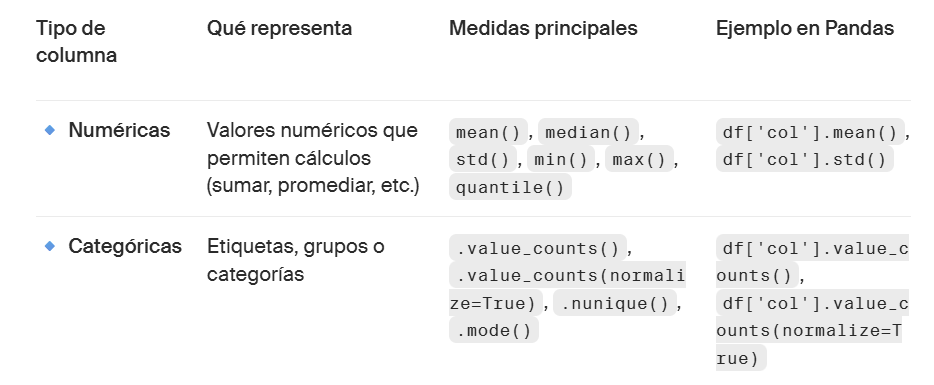

#MatPlot

In [ ]:
import matplotlib.pyplot as plt
df = pd.read_csv('/datasets/math_class.csv')

# Histograma con Matplotlib
plt.hist(df['score'], bins=10, color='skyblue', edgecolor='black')

plt.xlabel('Notas de los estudiantes')
plt.ylabel('Cantidad de estudianes')
plt.title('Distribución de notas')

plt.show()

#Seaborn

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('/datasets/math_class.csv')

# Histograma con Seaborn
sns.histplot(df['score'], bins=10, color='skyblue', kde=True)

plt.xlabel('Notas de los estudiantes')
plt.ylabel('Cantidad de estudianes')
plt.title('Distribución de notas')

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/datasets/everpeak_clean.csv')

plt.hist(df['price'], bins=10, color='skyblue', edgecolor='black')
plt.title('Histograma de precios sin ajuste')
plt.show()

In [ ]:
plt.hist(df['price'], bins=10, range=(12,1000), color='skyblue', edgecolor='black')
plt.title('Histograma de precios con ajuste de eje X')
plt.show()

In [ ]:
counts, bin_edges, _= plt.hist(df['price'], bins=10, range=(12,1000), color='skyblue', edgecolor='black')
plt.xticks(bin_edges)

plt.title('Histograma de precios con ajuste de eje X')
plt.show()

##**Ejercicio** 1 CApitulo 2 sprint 7


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/datasets/everpeak_clean.csv')

# Graficar histograma
counts, bin_edges, _ = plt.hist(df['price'], bins=10, range=(0,1000), color='skyblue', edgecolor='black')# Escribe tu código aquí

# Mostrar las marcas de los bins en el eje X
plt.xticks(bin_edges)

# Escribe tu código aquí

# Etiquetas y título del gráfico
plt.xlabel("Precio")# tu código aquí)
plt.ylabel("Cantidad")# tu código aquí)
plt.title("Distribución de Precios")# tu código aquí)
plt.show()

#Histograma Basico

In [ ]:
plt.hist(df['order_value'], bins=10, color='skyblue', edgecolor='black')
plt.title('Histograma de order_value sin ajuste')
plt.xlabel('Order value')
plt.ylabel('Count')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/datasets/everpeak_clean.csv')
df_toys = df[df["product_category"]=="Toys"]# tu código aquí

# Graficar BoxPlot

sns.boxplot(x=df_toys['quantity'], color='skyblue')
plt.title('Boxplot de Cantidades - Categoría Toys')
plt.xlabel('Cantidad Comprada')
plt.show()
# Etiquetas y título del gráfico
# tu código aquí

plt.show()

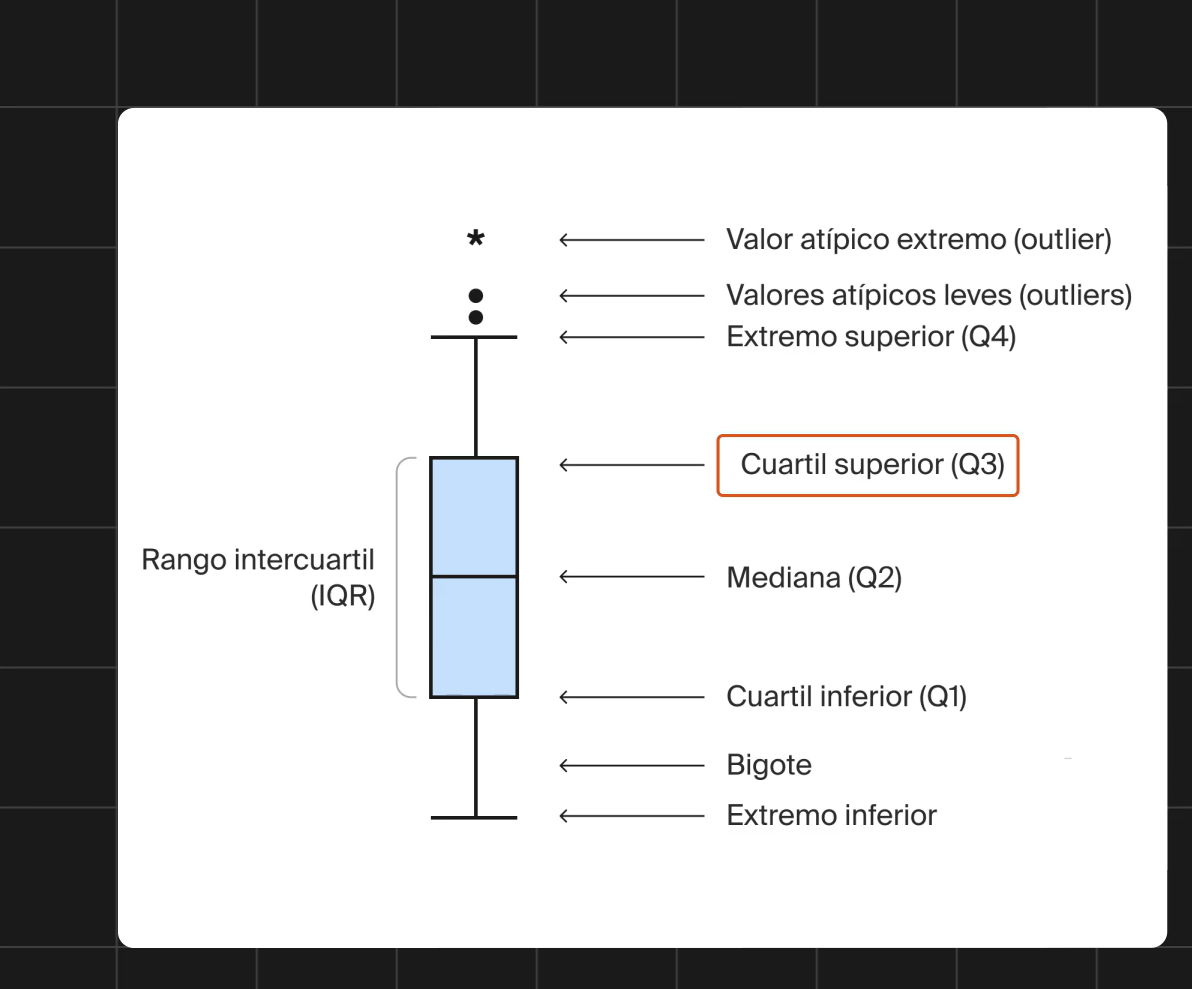

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv").head(50)

#calcular Q1
Q1 = df['price'].quantile(0.25)
print('Primer cuartil: ', Q1)

#calcular Q3
Q3 = df['price'].quantile(0.75)
print('Tercer cuartil: ', Q3)

#calcular IQR
IQR = Q3 - Q1
print('IQR: ', IQR)

sns.boxplot(data=df['price'])
plt.show()

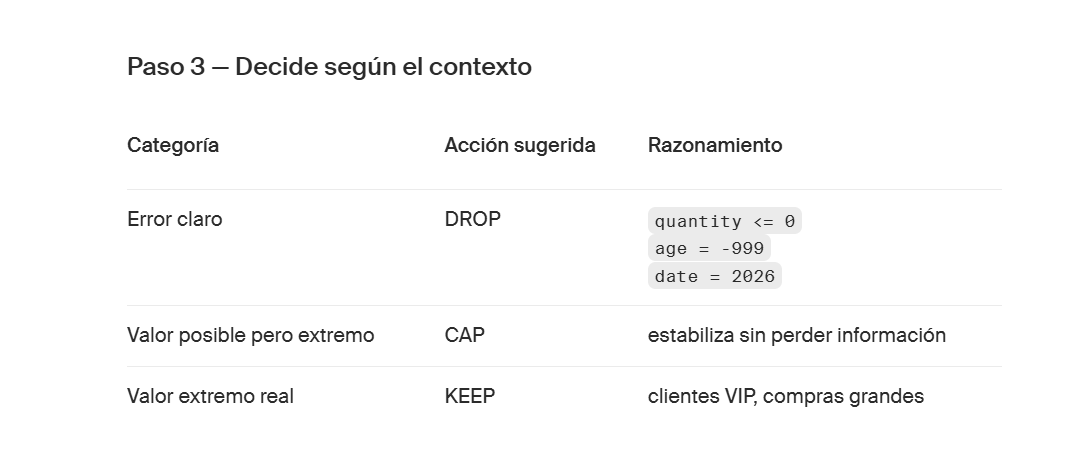

In [ ]:
Q1 = df['order_value'].quantile(0.25)
Q3 = df['order_value'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

outliers = df[df['order_value'] > upper]

In [ ]:
sns.histplot(df['col_name'])
plt.show()

sns.boxplot(x=df['col_name'])
plt.show()

In [ ]:
import pandas as pd
import numpy as np

#cargo los datos
df = pd.read_csv("/datasets/everpeak_clean.csv")

#calculo percentil 1 y 99
lower = df['price'].quantile(0.01)
upper = df['price'].quantile(0.99)

#crear columna con valores capados
df['price_winsor'] = np.clip(df['price'], lower, upper)


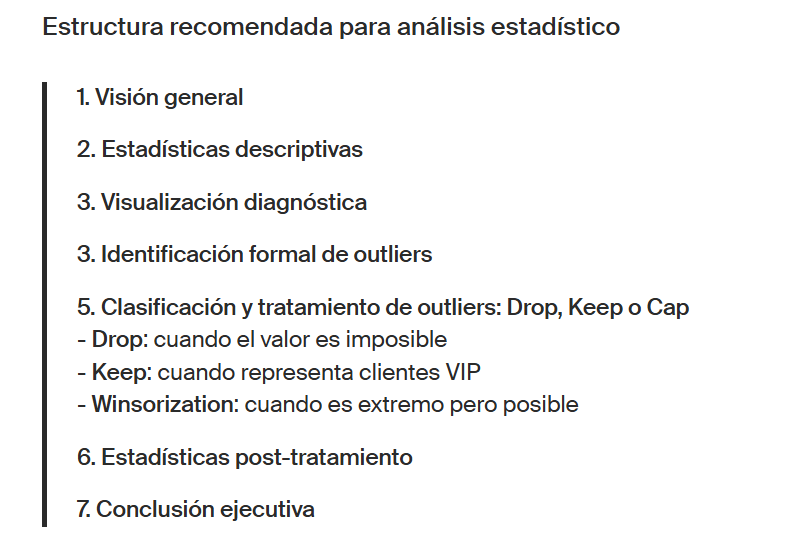

# EverPeak Retail Analysis – Sprint 6

Este repositorio contiene el análisis realizado durante el Sprint 6 del caso EverPeak–SilverBasket.

El dataset `everpeak_retail` incluye 2,000 órdenes de clientes con valores faltantes, sentinels, outliers y problemas de calidad diseñados para simular datos reales del retail. :contentReference[oaicite:2]{index=2}

## 📂 Contenido del repositorio

- `notebooks/everpeak_analysis.ipynb`
  → Notebook principal con limpieza, EDA, distribuciones, outliers y conclusiones.

## ▶ Cómo abrir el notebook en Google Colab

Haz clic en el siguiente botón:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](URL_DEL_NOTEBOOK_EN_GITHUB)

O:

1. Abre el archivo `.ipynb` en GitHub
2. Haz clic en **Open in Colab**

## 📘 Cómo reproducir el análisis

1. Abre `notebooks/everpeak_analysis.ipynb`
2. Ejecuta las celdas en orden
3. El notebook carga automáticamente el dataset desde `/data/` o desde un enlace público (según corresponda)

## 🧠 Objetivo del análisis

- Identificar problemas de calidad de datos
- Construir un pipeline de limpieza reproducible
- Analizar comportamientos, distribuciones y outliers
- Generar insights para el equipo de Estrategia e Integración de EverPeak

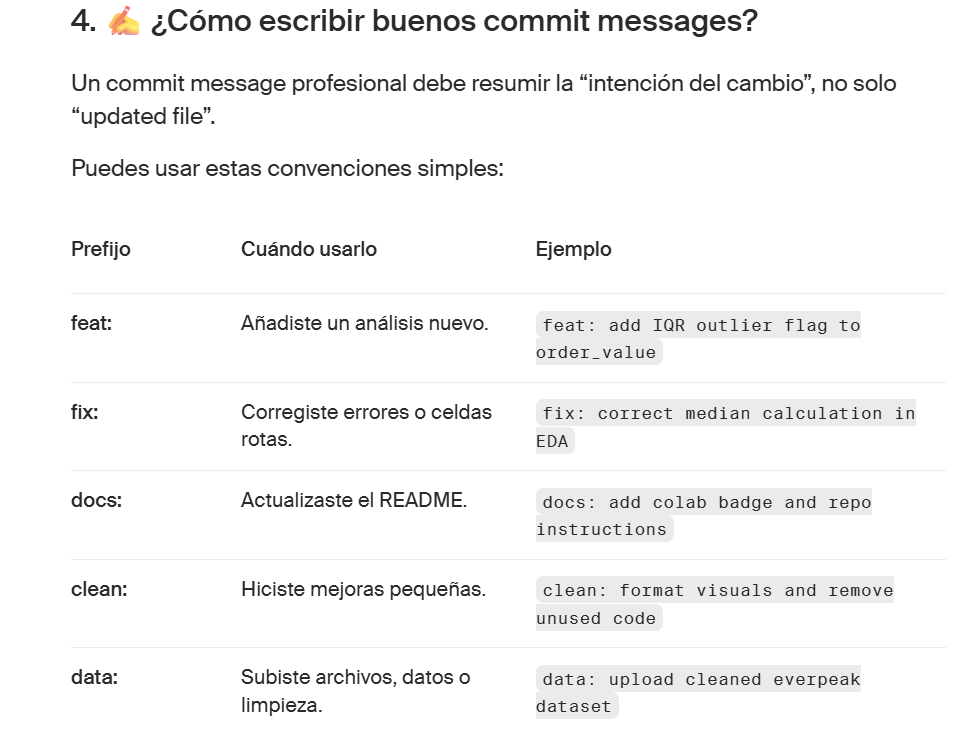

![image.png](
  
)